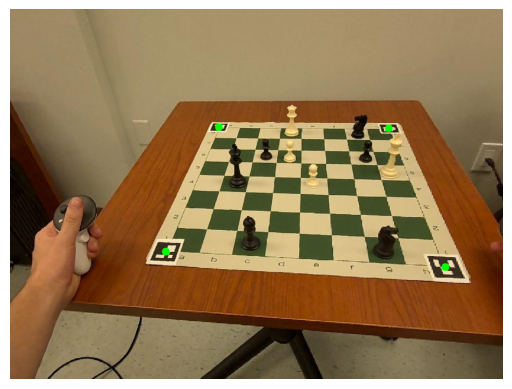

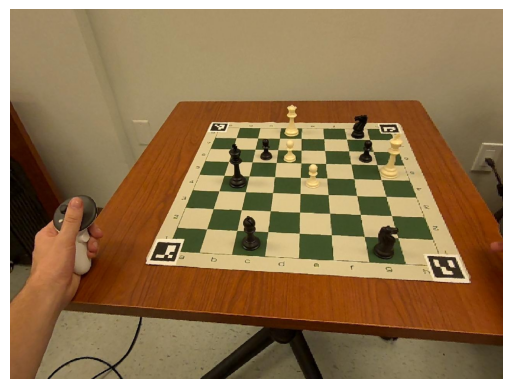

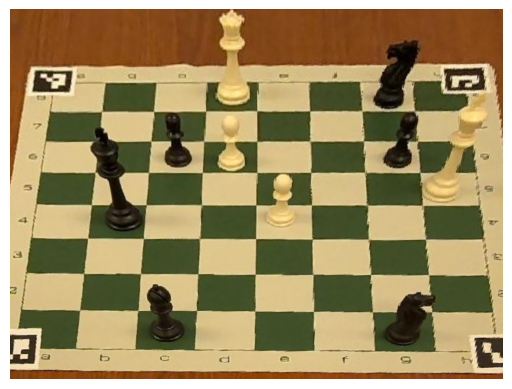

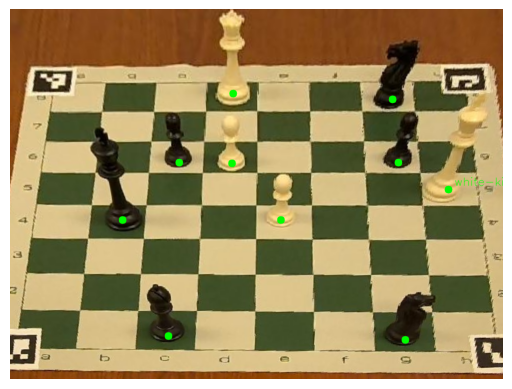

[['C8', 'black-bishop'], ['D4', 'white-pawn'], ['E5', 'white-pawn'], ['G8', 'black-knight'], ['G2', 'black-knight'], ['B5', 'black-king'], ['C4', 'black-pawn'], ['D2', 'white-queen'], ['G4', 'black-pawn'], ['H4', 'white-king']]
Best move is:  d2g2


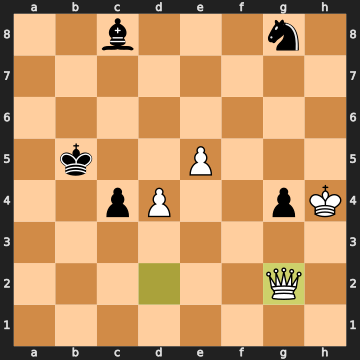

[]


In [ ]:
import cv2
import cv2.aruco as aruco

from inference_sdk import InferenceHTTPClient
import numpy as np

import matplotlib.pyplot as plt

import chess
import chess.svg
import requests

from IPython.display import SVG, display


from IPython.display import clear_output

def read_api_key(filepath=".secrets"):
    with open(filepath, "r") as file:
        return file.read().strip()

API_KEY = read_api_key()

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

WIDTH = 1280
HEIGHT = 960
boardCorners = []

### Board corners processing

def extractBoardCorners(points, pattern_size):
    points = points.reshape(pattern_size[1], pattern_size[0], 2)

    top_left = points[0, 0]
    top_right = points[0, -1]
    bottom_left = points[-1, 0]
    bottom_right = points[-1, -1]

    # Estimate cell size
    dx = (top_right - top_left) / (pattern_size[0] - 1)
    dy = (bottom_left - top_left) / (pattern_size[1] - 1)

    # Pull back the extrapolation slightly (0.5 is usually decent)
    scale = 0.5

    outer_top_left = top_left - scale * dx - scale * dy
    outer_top_right = top_right + scale * dx - scale * dy
    outer_bottom_left = bottom_left - scale * dx + scale * dy
    outer_bottom_right = bottom_right + scale * dx + scale * dy

    corners = [
        tuple(np.round(outer_top_left).astype(int)),
        tuple(np.round(outer_top_right).astype(int)),
        tuple(np.round(outer_bottom_left).astype(int)),
        tuple(np.round(outer_bottom_right).astype(int)),
    ]
    return corners

def getBoardCorners(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
    detector = aruco.ArucoDetector(aruco_dict)

    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None or len(ids) < 4:
        print(corners)
        print(ids)
        print("Not all ArUco markers detected.")
        return []

    ids = ids.flatten()
    marker_map = {id_: corner for id_, corner in zip(ids, corners)}

    def get_center(corner):
        pts = corner[0]
        return pts.mean(axis=0)

    corner_points = [
        get_center(marker_map[0]),  # top-left
        get_center(marker_map[1]),  # top-right
        get_center(marker_map[2]),  # bottom-left
        get_center(marker_map[3])   # bottom-right
    ]

    return corner_points
    

### Inference block

def parse_data(data):
    res = []
    heighCoef = 2.65

    for prediction in data.get("predictions", []):
        x, y, confidence, class_name = prediction["x"], prediction["y"] + \
            prediction["height"] / \
            heighCoef, prediction["confidence"], prediction["class"]
        res.append([x, y, confidence, class_name])

    return res

def converPointToPosition(point, corners):
    dictionary = {
        0: 'A',
        1: 'B',
        2: 'C',
        3: 'D',
        4: 'E',
        5: 'F',
        6: 'G',
        7: 'H',
    }

    width = corners[3][0] - corners[2][0]
    height = corners[2][1] - corners[0][1] + 60

    width_section = int(width / 8)
    height_section = int(height / 8)

    row = point[1] // height_section
    col = point[0] // width_section

    letter = dictionary.get(int(col), '?')

    if (int(row+1) < 1):
        return "-1"

    res = f"{letter}{int(row+1)}"

    return res

def converToFen(data):
    board = [['1' for _ in range(8)] for _ in range(8)]

    piece_map = {
        'black-pawn': 'p',
        'black-knight': 'n',
        'black-bishop': 'b',
        'black-rook': 'r',
        'black-queen': 'q',
        'black-king': 'k',
        'white-pawn': 'P',
        'white-knight': 'N',
        'white-bishop': 'B',
        'white-rook': 'R',
        'white-queen': 'Q',
        'white-king': 'K',
    }

    for tile, piece in data:
        col = ord(tile[0].upper()) - ord('A')
        row = 8 - int(tile[1])
        board[row][col] = piece_map[piece]

    fen_rows = []
    for row in board:
        fen_row = ""
        empty_count = 0
        for cell in row:
            if cell == '1':
                empty_count += 1
            else:
                if empty_count > 0:
                    fen_row += str(empty_count)
                    empty_count = 0
                fen_row += cell
        if empty_count > 0:
            fen_row += str(empty_count)
        fen_rows.append(fen_row)

    fen_piece_placement = "/".join(fen_rows)

    fen = f"{fen_piece_placement} w - - 0 1"

    return fen


def post_chess_api(data):
    url = "https://chess-api.com/v1"
    headers = {"Content-Type": "application/json"}
    payload = {"fen": data}

    try:
        response = requests.post(url, headers=headers, json=payload)

        response.raise_for_status()

        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error: {e}")
        return None
    
def getBestMove(image, corners):

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

    result = CLIENT.infer(image, model_id="chessscanner-w3y0i/2")
    data = parse_data(result)

    # Chnaging perspectie of the board

    imageCopy = image.copy()


    src_points = np.array(corners, dtype=np.float32)

    # Adding offset for top corners to capture full board

    src_points[0][1] -= 60
    src_points[1][1] -= 60

    src_points[0][0] -= 25
    src_points[1][0] += 25

    src_points[2][1] += 50
    src_points[3][1] += 50

    src_points[2][0] -= 20
    src_points[3][0] += 20



    dst_points = np.array([
        [0, 0],
        [WIDTH - 1, 0],
        [0, HEIGHT - 1],
        [WIDTH - 1, HEIGHT - 1]
    ], dtype=np.float32)

    matrix = cv2.getPerspectiveTransform(src_points, dst_points)
    warped_image = cv2.warpPerspective(imageCopy, matrix, (WIDTH, HEIGHT))

    image_rgb = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()


    # Mapping piece to new positions

    original_points = []

    for d in data:
        if d[0] > 0 and d[1] > 0:
            original_points.append([d[0], d[1]])

    original_points = np.array(original_points, dtype=np.float32)
    original_points = np.array([original_points])

    if (len(original_points[0]) < 1):
        print("ERROR: No pieces detected")
        return -1

    mapped_points = cv2.perspectiveTransform(original_points, matrix)
    
    finalImage = warped_image.copy()

    for i, mp in enumerate(mapped_points[0]):
        cv2.circle(finalImage, (int(mp[0]), int(mp[1])), 10, (0, 255, 0), -1) 

    label = data[i][3]  
    cv2.putText(
        finalImage, label, (int(mp[0]) + 15, int(mp[1]) - 10),  
        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA
    )

    image_rgb = cv2.cvtColor(finalImage, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()

    ### Creating FEN Board

    chessBoardData = []

    for i in range(len(data)):
        cvt = converPointToPosition(mapped_points[0][i], HEIGHT, WIDTH)
        
        if cvt[0] == '?' or cvt == '-1':
            print(mapped_points[0][i])
            continue

        chessBoardData.append([cvt, data[i][3]])

    print(chessBoardData)

    # Converting pos to fen and sending to the API

    fenData = converToFen(chessBoardData)

    board = chess.Board(fenData)
    board_svg = chess.svg.board(board=board)
    

    response_data = post_chess_api(fenData)
    if response_data:
        best_move = response_data.get("move")
        print("Best move is: ", best_move)

        if best_move:
            move = chess.Move.from_uci(best_move)
            if move in board.legal_moves:
                board.push(move)

            board_svg = chess.svg.board(board=board, lastmove=move, size=360)

            display(SVG(board_svg))



            with open("board.svg", "w") as f:
                f.write(board_svg)

        return []
    else:
        print("Error processing the chess_api")
        return -1

    

image = cv2.imread("test/1.jpg")
corners = getBoardCorners(image)

image_copy = image.copy()

# Draw each corner as a circle
for point in corners:
    x, y = map(int, point)
    cv2.circle(image_copy, (x, y), radius=10, color=(0, 255, 0), thickness=-1)  # green filled circle

# Convert BGR to RGB for Jupyter display
image_rgb = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()


res = getBestMove(image, corners)
print(res)